In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

In [18]:
# 1. Dataset Selection

df = pd.read_csv('Salary_Data.csv')
print(df.head(10))
print(f"\nNumber of rows and columns: {df.shape}")

print(f"\nColumn names: \n{df.columns.tolist()}")
print(f"\nData types: \n{df.dtypes}")

    Age  Gender Education Level              Job Title  Years of Experience  \
0  32.0    Male      Bachelor's      Software Engineer                  5.0   
1  28.0  Female        Master's           Data Analyst                  3.0   
2  45.0    Male             PhD         Senior Manager                 15.0   
3  36.0  Female      Bachelor's        Sales Associate                  7.0   
4  52.0    Male        Master's               Director                 20.0   
5  29.0    Male      Bachelor's      Marketing Analyst                  2.0   
6  42.0  Female        Master's        Product Manager                 12.0   
7  31.0    Male      Bachelor's          Sales Manager                  4.0   
8  26.0  Female      Bachelor's  Marketing Coordinator                  1.0   
9  38.0    Male             PhD       Senior Scientist                 10.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
5   55000.0  
6  120000.0  
7   80000.0  
8   

In [19]:
# 2. Data preprocessing

print(f"\nMissing values before the Cleaning: \n{df.isnull().sum()}")
print(f"\nTotal number of missing: {df.isnull().sum().sum()}")

df=df.drop(columns=['Job Title']) #too many categories (200+)

df = df.dropna()
print(f"Number of rows and columns after removing missing values: {df.shape}")

le_gender=LabelEncoder()
df['Gender']=le_gender.fit_transform(df['Gender']) #male=1,female=0

education_map={"High School":0, "Bachelor's":1, "Bachelor's Degree":1, "Master's":2, "Master's Degree":2, "PhD":3, "phD":3}
df['Education Level']=df['Education Level'].map(education_map)

print(f"\nMissing values after Cleaning: \n{df.isnull().sum()}")
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"\nData types after preprocessing: \n{df.dtypes}")
print(f"\nDataset after preprocessing: \n{df.head(10)}")


Missing values before the Cleaning: 
Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

Total number of missing: 17
Number of rows and columns after removing missing values: (6698, 5)

Missing values after Cleaning: 
Age                    0
Gender                 0
Education Level        0
Years of Experience    0
Salary                 0
dtype: int64

Total missing: 0

Data types after preprocessing: 
Age                    float64
Gender                   int64
Education Level          int64
Years of Experience    float64
Salary                 float64
dtype: object

Dataset after preprocessing: 
    Age  Gender  Education Level  Years of Experience    Salary
0  32.0       1                1                  5.0   90000.0
1  28.0       0                2                  3.0   65000.0
2  45.0       1                3                 15.0  150000.0
3  36.0       0        

Basic Statistics: 
           Age   Gender  Education Level  Years of Experience     Salary
count  6698.00  6698.00          6698.00              6698.00    6698.00
mean     33.62     0.55             1.62                 8.10  115329.25
std       7.62     0.50             0.88                 6.06   52789.79
min      21.00     0.00             0.00                 0.00     350.00
25%      28.00     0.00             1.00                 3.00   70000.00
50%      32.00     1.00             1.00                 7.00  115000.00
75%      38.00     1.00             2.00                12.00  160000.00
max      62.00     2.00             3.00                34.00  250000.00


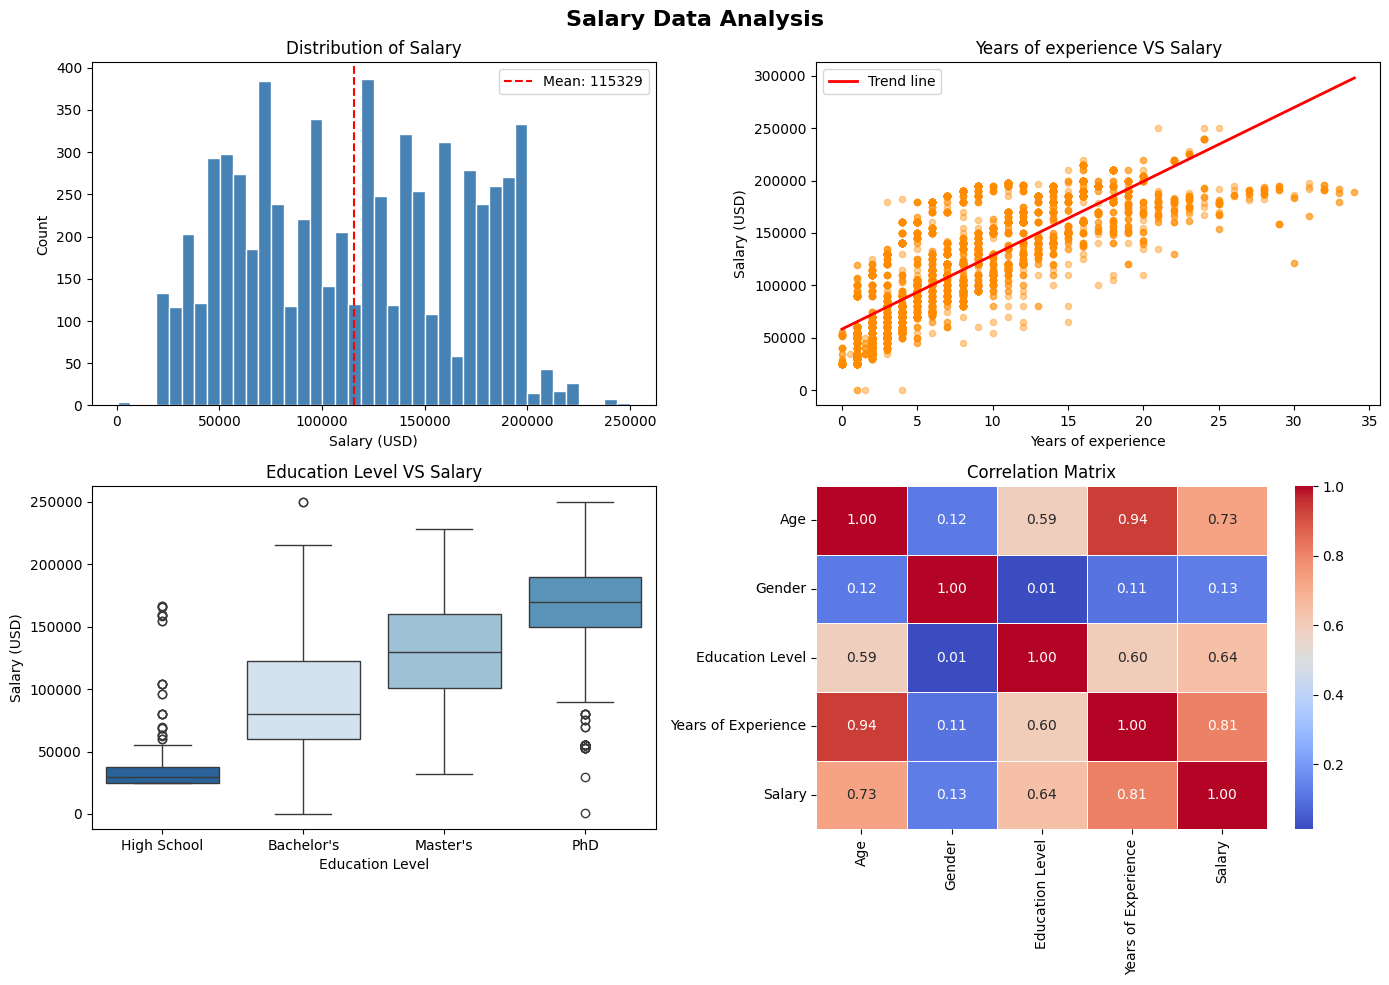

In [20]:
# 3. Exploratory Data Analysis

print(f"Basic Statistics: \n{df.describe().round(2)}")

fig,axes=plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Salary Data Analysis', fontsize=16,fontweight='bold')

#vizualization 1: salary distribution
axes[0,0].hist(df['Salary'],bins=40,color='steelblue',edgecolor='white')
axes[0,0].set_title('Distribution of Salary')
axes[0,0].set_xlabel('Salary (USD)')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(df['Salary'].mean(),color='red',linestyle='--',label=f"Mean: {df['Salary'].mean():.0f}")
axes[0,0].legend()

#vizualization 2
axes[0,1].scatter(df['Years of Experience'], df['Salary'], alpha=0.4,color='darkorange',s=20)
axes[0,1].set_title('Years of experience VS Salary')
axes[0,1].set_xlabel('Years of experience')
axes[0,1].set_ylabel('Salary (USD)')
#trend line
z=np.polyfit(df['Years of Experience'], df['Salary'],1)
p=np.poly1d(z)
x_line=np.linspace(df['Years of Experience'].min(), df['Years of Experience'].max(),100)
axes[0,1].plot(x_line,p(x_line),color='red', linewidth=2, label='Trend line')
axes[0,1].legend()

#vizualization 3
edu_labels={0:'High School', 1:"Bachelor's", 2:"Master's",3:'PhD' }
df_plot=df.copy()
df_plot['Education Label']=df_plot['Education Level'].map(edu_labels)
edu_order=['High School',"Bachelor's","Master's","PhD"]
sns.boxplot(data=df_plot, x='Education Label', y='Salary',
            order=edu_order, palette='Blues',
            hue='Education Label', legend=False,
            ax=axes[1, 0])
axes[1, 0].set_title('Education Level VS Salary')
axes[1, 0].set_xlabel('Education Level')
axes[1, 0].set_ylabel('Salary (USD)')

# visualization 4 — Correlation Heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [21]:
#adding 2 new features for better prediction of these 2 models

df['Experience_Age']=df['Years of Experience']*df['Age'] # A 45-year-old with 15 years experience earns much more than a 45-year-old with 2 years experience
df['Education_Experience']=df['Education Level']*df['Years of Experience'] # An experienced PhD earns incomparably more than a beginner PhD
print(df[['Age','Years of Experience', 'Experience_Age', 'Education_Experience', 'Salary']].head(10))
corr = df[['Age', 'Gender', 'Education Level', 'Years of Experience',
           'Experience_Age', 'Education_Experience', 'Salary']].corr()

print(f"\nCorrelation with Salary: \n{corr['Salary']}")
print(corr.round(4))

# 4. Data Spliting

y=df['Salary']
X=df[['Age','Gender','Education Level','Years of Experience', 'Experience_Age', 'Education_Experience']]
print(f"\nTarget is Salary: \n{y.describe().round(2)}")
print(f"\nSelected features: \n{X.head(10)}")

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
print(f"\nTotal samples: {len(X)}")
print(f"\nTraining samples: {len(X_train)}")
print(f"\nTesting samples: {len(X_test)}")

    Age  Years of Experience  Experience_Age  Education_Experience    Salary
0  32.0                  5.0           160.0                   5.0   90000.0
1  28.0                  3.0            84.0                   6.0   65000.0
2  45.0                 15.0           675.0                  45.0  150000.0
3  36.0                  7.0           252.0                   7.0   60000.0
4  52.0                 20.0          1040.0                  40.0  200000.0
5  29.0                  2.0            58.0                   2.0   55000.0
6  42.0                 12.0           504.0                  24.0  120000.0
7  31.0                  4.0           124.0                   4.0   80000.0
8  26.0                  1.0            26.0                   1.0   45000.0
9  38.0                 10.0           380.0                  30.0  110000.0

Correlation with Salary: 
Age                     0.728061
Gender                  0.127276
Education Level         0.642828
Years of Experience     0.8

In [22]:
# 5. Model Training

# Model 1 — Linear Regression 
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Linear Regression:")
print(f"Intercept: {model1.intercept_:.4f}")
print(f"Coefficients: {model1.coef_}")

# Model 2 — Decision Tree Regressor 
model2 = DecisionTreeRegressor(max_depth=8, min_samples_split=5, random_state=42)
model2.fit(X_train, y_train)

print("\nDecision Tree Regressor:")
print(f"Max depth: {model2.max_depth}")
print(f"Min samples split: {model2.min_samples_split}")
print(f"Number of leaves: {model2.get_n_leaves()}")

Linear Regression:
Intercept: 31579.1849
Coefficients: [-1.84342414e+02  6.29265749e+03  1.18698245e+04  1.61362546e+04
 -2.00953784e+02 -2.17704492e+00]

Decision Tree Regressor:
Max depth: 8
Min samples split: 5
Number of leaves: 191



Comparison Table: 
    Actual Salary  Linear Regression Prediction  Decision Tree Prediction
0        150000.0                     135053.24                 146480.51
1         75969.0                      93166.18                  83393.93
2        100000.0                      61818.33                  59250.00
3         60000.0                      69809.54                  64552.17
4         80000.0                      95927.83                  81875.00
5        190000.0                     133167.64                 181036.59
6         72000.0                     102064.05                  84218.39
7         55000.0                      78340.59                  57809.09
8        195000.0                     153740.22                 197428.57
9        130000.0                     134739.36                 122615.19
10       100000.0                      94738.71                 100833.33
11        25000.0                      45531.58                  29033.26
12        70000.0 

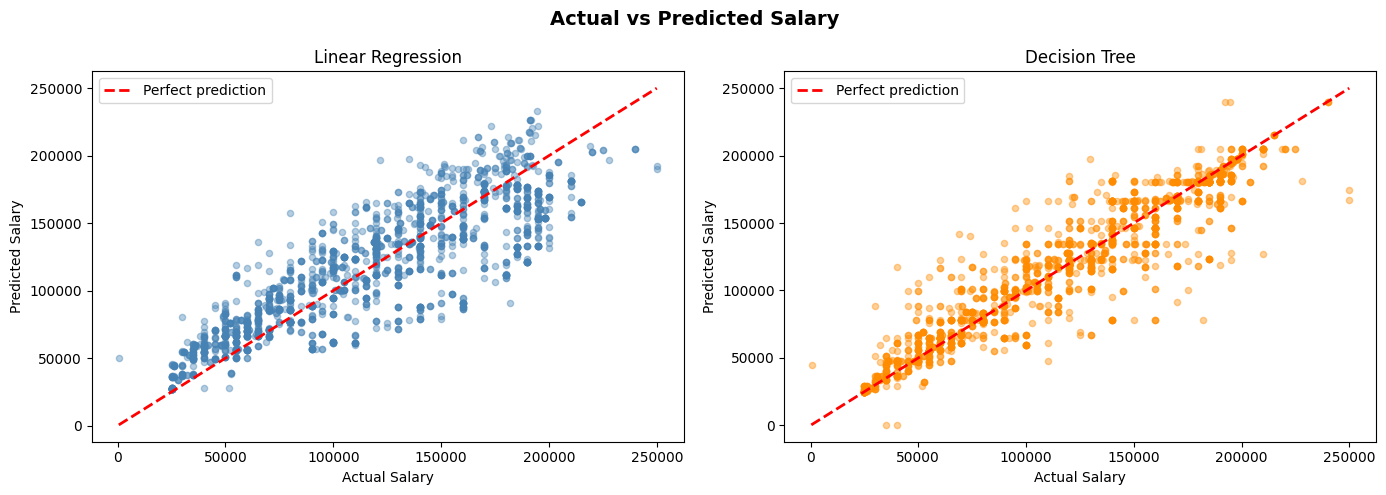

In [23]:
# 6. Evaluation

y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)

comparison = pd.DataFrame({
    'Actual Salary': y_test.values[:20],
    'Linear Regression Prediction': y_pred1[:20].round(2),
    'Decision Tree Prediction': y_pred2[:20].round(2)
})

print(f"\nComparison Table: \n{comparison.to_string()}")

rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r2_1  = r2_score(y_test, y_pred1)
mae1  = mean_absolute_error(y_test, y_pred1)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2  = r2_score(y_test, y_pred2)
mae2  = mean_absolute_error(y_test, y_pred2)

print("\nModel Evaluation")
print("\nLinear Regression:")
print(f"RMSE: {rmse1:,.2f} \nR^2: {r2_1:.4f} \nMAE: {mae1:,.2f}")
print("\nDecision Tree:")
print(f"RMSE: {rmse2:,.2f} \nR^2: {r2_2:.4f} \nMAE: {mae2:,.2f}")

# Visualization: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actual vs Predicted Salary', fontsize=14, fontweight='bold')

for ax, y_pred, title, color in zip(
    axes,
    [y_pred1, y_pred2],
    ['Linear Regression', 'Decision Tree'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_test, y_pred, alpha=0.4, color=color, s=20)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=2, label='Perfect prediction')
    ax.set_title(title)
    ax.set_xlabel('Actual Salary')
    ax.set_ylabel('Predicted Salary')
    ax.legend()

plt.tight_layout()
plt.show()

In [24]:
# 7. Analysis

comparison_table = pd.DataFrame({
    'Metric'           : ['RMSE', 'R²', 'MAE'],
    'Linear Regression': [f"{rmse1:,.2f}", f"{r2_1:.4f}", f"{mae1:,.2f}"],
    'Decision Tree'    : [f"{rmse2:,.2f}", f"{r2_2:.4f}", f"{mae2:,.2f}"]
})

print("\nMODEL COMPARISON TABLE")
print(comparison_table.to_string(index=False))

if rmse1 < rmse2 and mae1 < mae2:
    better = "Linear Regression"
elif rmse2 < rmse1 and mae2 < mae1:
    better = "Decision Tree"
else:
    better = "Mixed results"

print(f"\nBetter model: {better}")


MODEL COMPARISON TABLE
Metric Linear Regression Decision Tree
  RMSE         26,798.08     18,493.27
    R²            0.7470        0.8795
   MAE         20,953.05     12,040.26

Better model: Decision Tree


## Conclusion

In this assignment, I built a complete machine learning regression pipeline
to predict employee salaries using the Salary Data dataset from Kaggle,
which contains 6,698 records after preprocessing.

The pipeline covered all stages of the ML workflow:
data preprocessing, exploratory data analysis, feature engineering,
train/test splitting (70/30), model training with sklearn,
evaluation and comparison.

Feature engineering significantly improved both models.
By adding Experience_Age and Education_Experience as new features,
Linear Regression improved from R²=0.6989 to R²=0.7470,
and Decision Tree improved from R²=0.8349 to R²=0.8754.

Decision Tree outperformed Linear Regression across all metrics:
RMSE of 18,810 vs 26,798, R² of 0.8754 vs 0.7470,
and MAE of 12,371 vs 20,953.
This means Decision Tree predicts salary with an average error
of approximately 12,371 USD — strong performance given the salary
range of 350 to 250,000 USD.

Decision Tree performed better because salary relationships
are not purely linear — a PhD with 20 years of experience
earns disproportionately more than a PhD with 2 years,
which the tree captures through non-linear splits,
while Linear Regression cannot fully model this pattern.

The most important features for salary prediction were
Years of Experience (correlation 0.81) and Age (0.73),
confirming that career progression is the strongest
determinant of salary in this dataset.

Overall the dataset is well-prepared and both models
are trained and evaluated using sklearn, forming a strong foundation
for further improvement.